# Tau Bubble Chart

Interactive notebook to inspect country-year sector bubbles using `tau`, `tau_dir`, or `tau_amp`.
Bubble size uses sector `OUT` as a GDP proxy.

In [1]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz as viz
importlib.reload(viz)
prepare_country_bubble_data = viz.prepare_country_bubble_data
plot_country_bubble = viz.plot_country_bubble
import matplotlib.pyplot as plt

In [2]:
cfg = load_config('config/default.yaml')
country = 'CHN'
year = 2015
metric = 'tau'  # one of: tau, tau_dir, tau_amp

In [3]:
df = prepare_country_bubble_data(cfg=cfg, country=country, year=year, metric=metric)
label_top_n = len(df)
print(df[['label', 'sector_code', metric, 'out_proxy']].head(10).to_string(index=False))
print(f'rows={len(df)}  country={country}  year={year}  metric={metric}')

     label sector_code      tau    out_proxy
   CHN_A01         A01 0.049574 1574596.3445
   CHN_A02         A02 0.042658  102938.8339
   CHN_A03         A03 0.031023  184598.6962
   CHN_B05         B05 0.058920  339930.6725
   CHN_B07         B07 0.105948  207272.5344
   CHN_B08         B08 0.103550  131598.4796
   CHN_B09         B09 0.161878   25592.1977
CHN_C10T12      C10T12 0.040005 1717616.0934
CHN_C13T15      C13T15 0.046415 1346182.8241
   CHN_C16         C16 0.054878  243892.4217
rows=48  country=CHN  year=2015  metric=tau


<Figure size 1400x600 with 0 Axes>

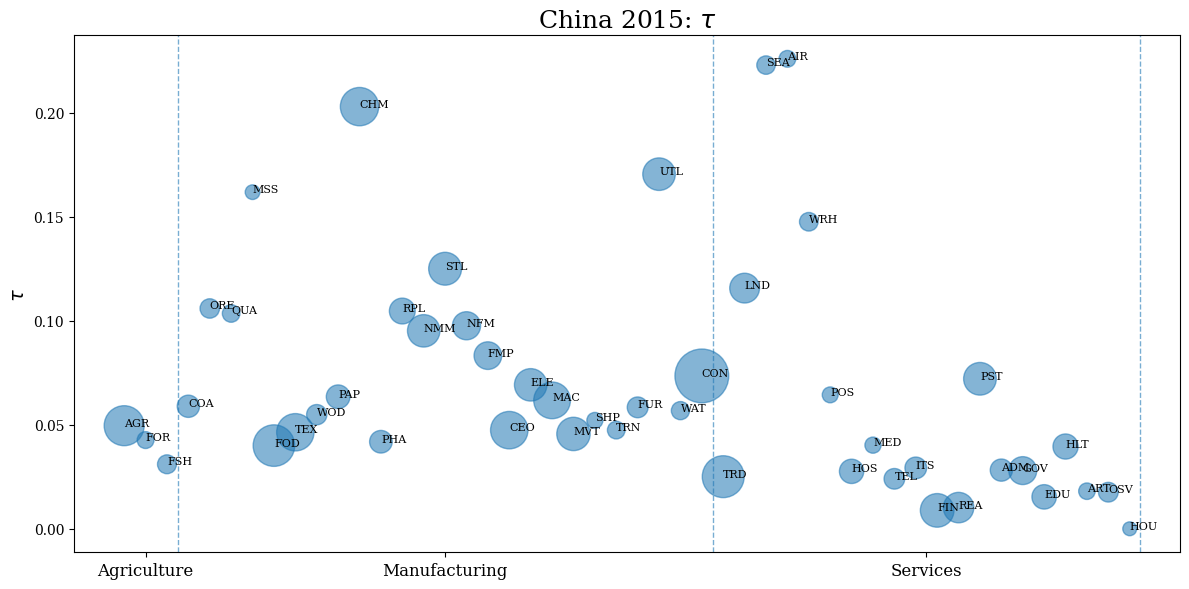

In [4]:
plt.figure(figsize=(14, 6))
metric_labels = {'tau': r'$\tau$', 'tau_dir': r'$\tau_{dir}$', 'tau_amp': r'$\tau_{amp}$'}
metric_label = metric_labels.get(metric, metric)
country_name = df['country_name'].dropna().iloc[0] if 'country_name' in df.columns and df['country_name'].notna().any() else country
title = f"{country_name} {year}: {metric_label}"
ax = plot_country_bubble(df, metric=metric, title=title, label_top_n=label_top_n)
plt.tight_layout()
plt.show()

## Try Different Inputs

- Change `country` (e.g., `USA`, `DEU`, `JPN`)
- Change `year` (1995-2022)
- Change `metric` (`tau`, `tau_dir`, `tau_amp`)